# TP3 : Algorithme Bayésien Naïf

### Identification de l'étudiant

In [72]:
# Nom : 
# Prénom : 
# Numéro d'étudiant : 

### Modalités de rendu

1. Chaque étudiant doit rendre un travail individuel.
2. Renommez ce fichier selon la convention : `TP1_Nom_Prenom.ipynb`.
3. Le rendu s'effectuera via le lien de dépôt communiqué par votre enseignant.
4. Assurez-vous que votre code s'exécute sans erreur (Menu : Kernel > Restart & Run All).

### Objectifs de la séance

Ce TP a pour objectif l’implémentation d'un algorithme Bayésien Naïf que l'on utilisera pour faire une analyse de sentiments sur des critiques de film.

Les performances des modèles seront évaluées et comparées à l’aide de métriques standards, notamment :
- la matrice de confusion,
- la précision (precision) et rappel (recall).
- ROC, AUC

### Documentation utile
- [Numpy User Guide](https://numpy.org/doc/stable/user/index.html)
- [Scikit-Learn OpenML](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_openml.html)


## Organisation du TP

Ce TP contient 2 parties :

1. **Tokeniser, Lemmatiser et Vectoriser un ensemble de phrases**
2. **Implémentation et Comparaison d'algorithmes Bayésiens Naïfs**

# Partie 1 — Tokeniser, Lemmatiser et Vectoriser un ensemble de phrases

## Importation des modules

In [73]:
import numpy as np
import pandas as pd
import scipy as sp
import matplotlib.pyplot as plt
import wordcloud

In [74]:
import nltk
from nltk.corpus import stopwords
from nltk.corpus import wordnet
from nltk.stem import WordNetLemmatizer

In [75]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import RocCurveDisplay, ConfusionMatrixDisplay, precision_score, recall_score, confusion_matrix

In [76]:
from pprint import pprint

## Téléchargement des ressources pour NLTK

In [77]:
nltk.download('stopwords')
nltk.download('punkt_tab')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\marco\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\marco\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\marco\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\marco\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\marco\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


True

## Concepts de base

Considérons quelques critiques simples:

In [78]:
reviews = [
    "I loved every second of this masterpiece!",
    "The actors were terrible and the story was boring.",
    "Amazing music and great special effects!",
    "I would rather watch paint dry than see this movie.",
    "A complete waste of time and money!",
    "Don't miss this masterpiece!"
]

La première étapde en général consiste à mettre tout en lettres minuscules:

In [79]:
# Complétez les points de suspension
# Utilisez la méthode lower() pour mettre toutes les reviews en minuscule

reviews = [review.lower() for review in reviews]
pprint(reviews)

['i loved every second of this masterpiece!',
 'the actors were terrible and the story was boring.',
 'amazing music and great special effects!',
 'i would rather watch paint dry than see this movie.',
 'a complete waste of time and money!',
 "don't miss this masterpiece!"]


Ensuite on découpe la phrase en **tokens**: c'est la tokenisation.

On ne souhaite pas garder les signes de ponctuation:

In [80]:
def has_letter_digit(word):
    # Retourne vrai si le mot contient au moins un caractère alphanumérique
    for item in word:
        if item.isalnum():
            return True
    return False

# Utilisez la méthode word_tokenise pour découper la phrase en token
# en excluant ceux qui n'ont pas de caractère alphanumérique
for review in reviews:
    tokens = [word for word in nltk.word_tokenize(review) if has_letter_digit(word)]
    print(tokens)

['i', 'loved', 'every', 'second', 'of', 'this', 'masterpiece']
['the', 'actors', 'were', 'terrible', 'and', 'the', 'story', 'was', 'boring']
['amazing', 'music', 'and', 'great', 'special', 'effects']
['i', 'would', 'rather', 'watch', 'paint', 'dry', 'than', 'see', 'this', 'movie']
['a', 'complete', 'waste', 'of', 'time', 'and', 'money']
['do', "n't", 'miss', 'this', 'masterpiece']


Il y a plein de tokens qui n'apportent pas de sens, ce sont des mots vides, ou encore stop-words.

Recommençont l'opération en excluant cette fois les stop-words :

In [81]:
stop_words = set(stopwords.words('english'))
negations = {'not', 'nor', 'neither'}  # on garde ces tokens parce qu'ils peuvent influencer le sentiment
stop_words -= negations
#quelques exemples de stop word
print(list(stop_words)[0:10])

# On recommence l'opération précédente : 
# Utilisez la méthode word_tokenise() pour découper la phrase en token
# en excluant ceux qui n'ont pas de caractère alphanumérique
for review in reviews:
    tokens = [word for word in nltk.word_tokenize(review) if has_letter_digit(word) and word not in stop_words]
    print(tokens)

['you', "won't", "it'd", 'been', 'an', 'will', "they'd", 'once', 'its', 'those']
['loved', 'every', 'second', 'masterpiece']
['actors', 'terrible', 'story', 'boring']
['amazing', 'music', 'great', 'special', 'effects']
['would', 'rather', 'watch', 'paint', 'dry', 'see', 'movie']
['complete', 'waste', 'time', 'money']
["n't", 'miss', 'masterpiece']


Enfin, on veut lemmatiser pour simplifier encore. La lemmatisation consiste par exemple à remplacer les pluriels par des singuliers ou à remplacer un verbe conjugué par un verbe à l'infinitif:

Recommençont l'opération en lemmatisant au préalable chaque mot des différentes reviews :

In [82]:
# Utilisez la méthode lemmatize() de la classe WordNetLemmatizer() pour lemmatiser chaque token

for review in reviews:
    wnl = WordNetLemmatizer()
    tokens = [wnl.lemmatize(word) for word in nltk.word_tokenize(review) if has_letter_digit(word) and word not in stop_words]
    print(tokens)

['loved', 'every', 'second', 'masterpiece']
['actor', 'terrible', 'story', 'boring']
['amazing', 'music', 'great', 'special', 'effect']
['would', 'rather', 'watch', 'paint', 'dry', 'see', 'movie']
['complete', 'waste', 'time', 'money']
["n't", 'miss', 'masterpiece']


La lemmatisation peut ne pas fonctionner correctement. Par exemple *loved* peut être un adjectif ou un verbe. Pour afiner le traitement, on peut avoir besoin de détecter la structure grammaticale de la phrase, ce qui est appelé Part Of Speech (POS):

- **Vxx**: verbe
- **Jxx**: adjectif
- **Nxx**: nom
- **Pxx**: pronom
- **Rxx**: adverbe
- **.**: ponctuation
- **DT**: déterminent
- **CC**: conjonction de coordination
- **IN**: conjonction ou préposition
- **MD**: modal

In [83]:
# La méthode pos_tag() détecte la structure grammaticale
for review in reviews:
    tokens = nltk.word_tokenize(review)
    pos = nltk.pos_tag(tokens)
    print(pos)

[('i', 'NN'), ('loved', 'VBD'), ('every', 'DT'), ('second', 'NN'), ('of', 'IN'), ('this', 'DT'), ('masterpiece', 'NN'), ('!', '.')]
[('the', 'DT'), ('actors', 'NNS'), ('were', 'VBD'), ('terrible', 'JJ'), ('and', 'CC'), ('the', 'DT'), ('story', 'NN'), ('was', 'VBD'), ('boring', 'VBG'), ('.', '.')]
[('amazing', 'JJ'), ('music', 'NN'), ('and', 'CC'), ('great', 'JJ'), ('special', 'JJ'), ('effects', 'NNS'), ('!', '.')]
[('i', 'NN'), ('would', 'MD'), ('rather', 'RB'), ('watch', 'VB'), ('paint', 'NN'), ('dry', 'JJ'), ('than', 'IN'), ('see', 'VB'), ('this', 'DT'), ('movie', 'NN'), ('.', '.')]
[('a', 'DT'), ('complete', 'JJ'), ('waste', 'NN'), ('of', 'IN'), ('time', 'NN'), ('and', 'CC'), ('money', 'NN'), ('!', '.')]
[('do', 'VBP'), ("n't", 'RB'), ('miss', 'VB'), ('this', 'DT'), ('masterpiece', 'NN'), ('!', '.')]


Quand on fait la lemmatisation, on peut préciser le POS afin d'afiner le traitement:

In [84]:
for review in reviews:
    wnl = WordNetLemmatizer()
    tokens = nltk.word_tokenize(review)
    pos_tokens = nltk.pos_tag(tokens)
    dct = {'J': wordnet.ADJ, 'V': wordnet.VERB, 'N': wordnet.NOUN, 'R': wordnet.ADV}
    out = []
    for token, pos in zip(tokens, pos_tokens):
        if token in stop_words or pos[1][0] in ('.', 'D', 'M'):
            # On ignore les tokens dans les stop-words, les signes de ponctuations et les déterminents
            continue
        out.append(wnl.lemmatize(token, dct[pos[1][0]]))
    print(out)

['love', 'second', 'masterpiece']
['actor', 'terrible', 'story', 'bore']
['amazing', 'music', 'great', 'special', 'effect']
['rather', 'watch', 'paint', 'dry', 'see', 'movie']
['complete', 'waste', 'time', 'money']
["n't", 'miss', 'masterpiece']


*loved* a été simplifié en *love*

## Vectorisation

Dans cette section nous verrons comment on peut vectoriser une critique de film. Dans un premier temps, nous allons créer une fonction de tokenisation personnalisée pour sklearn:

In [85]:
def has_letter_digit(word):
    # Retourne vrai si le mot contient au moins un caractère alphanumérique
    for item in word:
        if item.isalnum():
            return True
    return False

def has_symbol(word):
    # Retourne vrai si le mot contient un symbole
    for item in word:
        if item in ['/', '\\', '+', '=', '_', '.', '$', '£']:
            return True
    return False
    
def tokenizer():
    stop_words = set(stopwords.words('english'))
    negations = {'not', 'nor', 'neither'}  # on garde ces tokens parce qu'ils peuvent influencer le sentiment
    stop_words -= negations
    wnl = WordNetLemmatizer()
    dct = {'J': wordnet.ADJ, 'V': wordnet.VERB, 'N': wordnet.NOUN, 'R': wordnet.ADV}
    pos_removed = {'.', ',', ':', ';', '`', "'", '$', 'C', 'D', 'M', 'I', 'P', 'W', 'U', 'F', 'S', 'E', 'T', 'L'}
    def inner(review):
        tokens = nltk.word_tokenize(review)
        pos_tokens = nltk.pos_tag(tokens)
        out = []
        for token, pos in zip(tokens, pos_tokens):
            pos0 = pos[1][0]
            if token in stop_words or pos0 in pos_removed:
               # On ignore les token dans les stop-words et certains POS
               continue
            if has_letter_digit(token) and not has_symbol(token):
                out.append(wnl.lemmatize(token, dct[pos0]))
        return out
    return inner

Maintenant que nous avons de quoi tokeniser et lématiser les critiques, On doit convertir ces données en données numériques pour qu'elles puissent être traitées par un algorithme d'apprentissage automatique. Cette opération peut être réalisée par une opération simple de **vectorisation par comptage**.

In [86]:
# Entraîner un CountVectorizer (stop_words=None, tokenizer=tokenizer(), token_pattern=None) sur reviews

cnt = CountVectorizer(stop_words=None, tokenizer=tokenizer(), token_pattern=None)
cnt.fit(reviews);

In [87]:
features = cnt.get_feature_names_out()
features

array(['actor', 'amazing', 'bore', 'complete', 'dry', 'effect', 'great',
       'love', 'masterpiece', 'miss', 'money', 'movie', 'music', "n't",
       'paint', 'rather', 'second', 'see', 'special', 'story', 'terrible',
       'time', 'waste', 'watch'], dtype=object)

Il est également possible de former des n-grammes afin de prendre en compte quelques interactions de mots. Les n-grammes sont des interactions de mots.
Par exemple dans la phrase: *il fait très beau*, la tokenisation pourrait donner par exemple `['fait', 'très', 'beau']`. Ce sont des 1-grammes. Les 2-grammes seraient: `['fait très', 'très beau']`. Et il y aurait un seul 3-gramme: `['fait très beau']`.

Dans le code ci-dessous on extrait les 1-grammes et les 2-grammes:

In [88]:
# Pour extraire les 1-gralles jusqu'au n-grammes, il faut ajouter en paramètre ngram_range=(1,n).
# Ici, on veut n=2

cnt = CountVectorizer(stop_words=None, tokenizer=tokenizer(), token_pattern=None, ngram_range=(1,2))
cnt.fit(reviews);

In [89]:
features = cnt.get_feature_names_out()
features

array(['actor', 'actor terrible', 'amazing', 'amazing music', 'bore',
       'complete', 'complete waste', 'dry', 'dry see', 'effect', 'great',
       'great special', 'love', 'love second', 'masterpiece', 'miss',
       'miss masterpiece', 'money', 'movie', 'music', 'music great',
       "n't", "n't miss", 'paint', 'paint dry', 'rather', 'rather watch',
       'second', 'second masterpiece', 'see', 'see movie', 'special',
       'special effect', 'story', 'story bore', 'terrible',
       'terrible story', 'time', 'time money', 'waste', 'waste time',
       'watch', 'watch paint'], dtype=object)

# Partie 2 — Implémentation et Comparaison d'algorithmes Bayésiens Naïfs

## Application à un dataset réel IMDb

Nous allons maintenant appliquer ça à une base de données de critiques de films publiées sur le site IMDb. Le dataset est publique mais il a été téléchargé depuis ce lien sur Kaggle:

https://www.kaggle.com/datasets/yasserh/imdb-movie-ratings-sentiment-analysis

### Exploration des données

In [90]:
# Mettre le lien l'emplacement du fichier télécharger en argument

df = pd.read_csv(".\moviedb\movie.csv")

Utilisez la méthode `info()` pour inspecter le type des variables (float, int, category) et repérer le nombre de valeurs non-nulles.

In [91]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    40000 non-null  object
 1   label   40000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 625.1+ KB


Nous avons deux colonnes. Une première qui contient le texte de la critique et une seconde avec une variable discrète: 1: revue positive, 0: revue négative.

Utilisez la méthode `value_counts()` pour regarder les effectifs de chaque classe.

In [92]:
df["label"].value_counts()

0    20019
1    19981
Name: label, dtype: int64

Le dataset est équilibré entre les revues positives et les revues négatives.

Visualisation de quelques revues courtes:

In [93]:
mask = df["text"].str.len() <= 100
for l in df.loc[mask, "text"]:
    print(l)
    print("----")

I don't know why I like this movie so well, but I never get tired of watching it.
----
no comment - stupid movie, acting average or worse... screenplay - no sense at all... SKIP IT!
----
Ming The Merciless does a little Bardwork and a movie most foul!
----
A rating of "1" does not begin to express how dull, depressing and relentlessly bad this movie is.
----
If you like Pauly Shore, you'll love Son in Law. If you hate Pauly Shore, then, well...I liked it!
----
You'd better choose Paul Verhoeven's even if you have watched it.
----
Just love the interplay between two great characters of stage & screen - Veidt & Barrymore
----
More suspenseful, more subtle, much, much more disturbing....
----
What a script, what a story, what a mess!
----
Long, boring, blasphemous. Never have I been so glad to see ending credits roll.
----
Adrian Pasdar is excellent is this film. He makes a fascinating woman.
----
Read the book, forget the movie!
----
I wouldn't rent this one even on dollar rental night.


On peut maintenant tester notre méthode pour transformer la donnée:

In [94]:
df_short = df[mask].copy()

In [95]:
# On ne prend en compte que les 1-gramme pour le moment
cnt = CountVectorizer(stop_words=None, tokenizer=tokenizer(), token_pattern=None)
cnt.fit(df_short["text"]);

In [96]:
# On regarde comment certaines des reviews ont été transformé

features = cnt.get_feature_names_out()
array = cnt.transform(df_short["text"]).toarray()

for i, row in enumerate(df_short.iterrows()):
    print(row[1]["text"])
    print(" => ", features[array[i].astype(bool)])

I don't know why I like this movie so well, but I never get tired of watching it.
 =>  ['get' 'know' 'movie' "n't" 'never' 'tire' 'watch' 'well']
no comment - stupid movie, acting average or worse... screenplay - no sense at all... SKIP IT!
 =>  ['act' 'average' 'bad' 'comment' 'movie' 'screenplay' 'sense' 'skip'
 'stupid']
Ming The Merciless does a little Bardwork and a movie most foul!
 =>  ['bardwork' 'foul' 'little' 'merciless' 'ming' 'movie']
A rating of "1" does not begin to express how dull, depressing and relentlessly bad this movie is.
 =>  ['bad' 'begin' 'depressing' 'dull' 'express' 'movie' 'not' 'rating'
 'relentlessly']
If you like Pauly Shore, you'll love Son in Law. If you hate Pauly Shore, then, well...I liked it!
 =>  ['hate' 'law' 'like' 'love' 'pauly' 'shore' 'son' 'well']
You'd better choose Paul Verhoeven's even if you have watched it.
 =>  ['better' 'choose' 'even' 'verhoeven' 'watch']
Just love the interplay between two great characters of stage & screen - Veidt 

### Modèle avec 1000 données

On ne gardera qu'un échantillon de 1000 revues pour l'apprentissage et le test du modèle.

In [97]:
df_sample = df.sample(1000, random_state=14)

In [98]:
# On veut maintenant séparer notre dataset en 2, un set d'entrainement et un set de test
# On utilise la méthode train_test_split() et on veut que la taille du test de test soit 20% du dataset original.

df_train, df_test = train_test_split(df_sample, test_size=0.20)

In [99]:
cnt = CountVectorizer(stop_words=None, tokenizer=tokenizer(), token_pattern=None)
cnt.fit(df_train["text"]);

In [100]:
features = cnt.get_feature_names_out()
x_train = cnt.transform(df_train["text"])  # on garde maintenant le tableau creux !
y_train = df_train["label"].to_numpy()

On créé l'algorithme Bayésien Naïf. On lui demande explicitement de ne pas apprendre de probabilité a priori à partir des données et on lui donne explicitement la probabilité a priori. Si on ne fait pas ça, l'algorithme calcule la probabilité a priori à partir de la répartition des critiques positives et négatives dans les données d'apprentissage:

In [101]:
# Entraîner un MultinomialNB(class_prior=np.array([0.5, 0.5]), fit_prior=False) sur notre set d'entrainement.

clf = MultinomialNB(class_prior=np.array([0.5, 0.5]), fit_prior=False)
clf.fit(x_train, y_train);

In [102]:
# On regarde les prédictions de notre modèle sur notre set de test.
# On utilise pour ça la méthode predict_proba()

x_test = cnt.transform(df_test["text"])
y_test = df_test["label"].to_numpy()
p_hat = clf.predict_proba(x_test)[:,1]  # on ne garde que les probabilités de la classe "positive"

Cette fonction de sklearn permet de tracer la courbe ROC à partir des probabilités prédites:

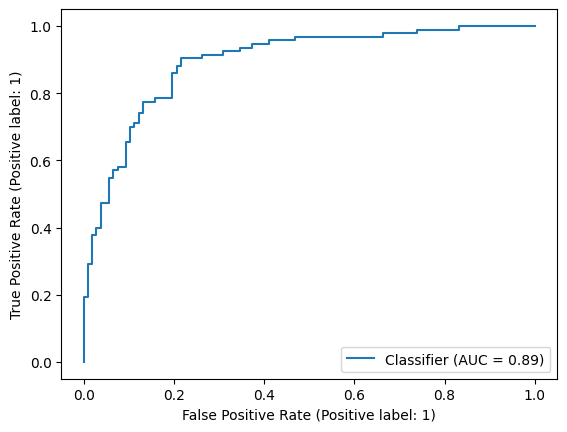

In [103]:
# On veut utiliser une la méthode from_predictions() de la classe RocCurveDisplay.
# Mettez les bons arguments dans la méthode

RocCurveDisplay.from_predictions(y_test, p_hat);

Et cette fonction permet d'afficher la matrice de confusion pou run seuil de décision à 0.5:

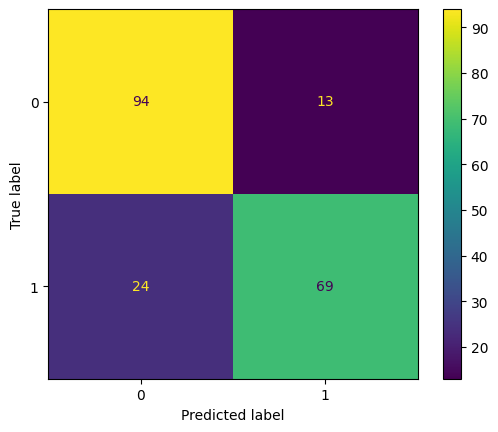

In [104]:
# On veut utiliser une la méthode from_predictions() de la classe ConfusionMatrixDisplay.

ConfusionMatrixDisplay.from_predictions(y_test, np.where(p_hat>=0.5, 1, 0));

### Modèle avec 1000 données et des n-grammes

On ne gardera qu'un échantillon de 1000 revues pour l'apprentissage et le test du modèle, mais on rajoute les 2-grammes ;)

In [105]:
df_sample = df.sample(1000, random_state=14)

In [106]:
# On veut maintenant séparer notre dataset en 2, un set d'entrainement et un set de test
# On utilise la méthode train_test_split() et on veut que la taille du test de test soit 20% du dataset original.

df_train, df_test = train_test_split(df_sample, test_size=0.20)

In [107]:
cnt = CountVectorizer(stop_words=None, tokenizer=tokenizer(), token_pattern=None, ngram_range=(1, 2))
cnt.fit(df_train["text"]);

In [108]:
features = cnt.get_feature_names_out()
features

array(["'40", "'40 quite", "'40s", ..., 'ça traîne', 'é', 'é dia'],
      dtype=object)

Cela fait beaucoup de caractéristiques ! C'est pour celà que l'on veut travailler avec des tableaux creux:

In [109]:
# Entraîner un MultinomialNB(class_prior=np.array([0.5, 0.5]), fit_prior=False) sur notre set d'entrainement.

clf = MultinomialNB(class_prior=np.array([0.5, 0.5]), fit_prior=False)
x_train = cnt.transform(df_train["text"])
y_train = df_train["label"].to_numpy()
clf.fit(x_train, y_train);

In [110]:
# On regarde les prédictions de notre modèle sur notre set de test.
# On utilise pour ça la méthode predict_proba()

x_test = cnt.transform(df_test["text"])
y_test = df_test["label"].to_numpy()
p_hat = clf.predict_proba(x_test)[:,1]

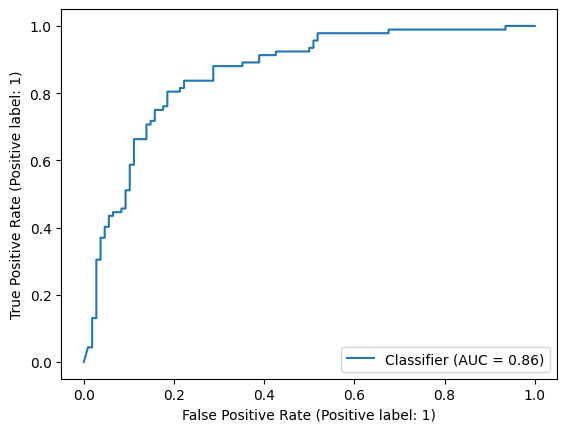

In [111]:
# On veut utiliser une la méthode from_predictions() de la classe RocCurveDisplay.
# Mettez les bons arguments dans la méthode

RocCurveDisplay.from_predictions(y_test, p_hat);

Matrice de confusion avec un seuil de 0.5:

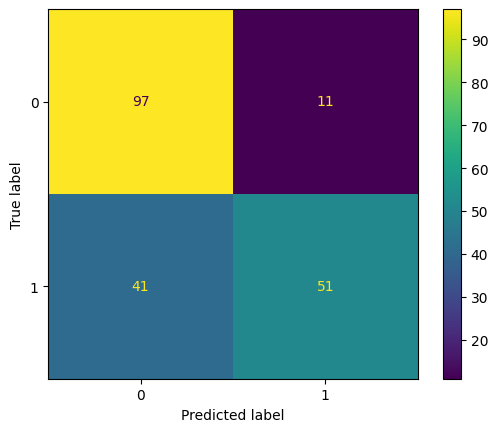

In [112]:
# On veut utiliser une la méthode from_predictions() de la classe ConfusionMatrixDisplay.

ConfusionMatrixDisplay.from_predictions(y_test, np.where(p_hat>=0.5, 1, 0));

### Modèle avec 5000 données et des n-grammes

On ne gardera qu'un échantillon de 5000 revues pour l'apprentissage et le test du modèle.

In [113]:
df_sample = df.sample(5000, random_state=14)

In [114]:
df_train, df_test = train_test_split(df_sample, test_size=0.20)

In [115]:
# Pour extraire les 1-gralles jusqu'au n-grammes, il faut ajouter en paramètre ngram_range=(1,n).
# Ici, on veut n=2

cnt = CountVectorizer(stop_words=None, tokenizer=tokenizer(), token_pattern=None, ngram_range=(1, 2))
cnt.fit(df_train["text"]);

In [116]:
features = cnt.get_feature_names_out()
features

array(["'00s", "'00s nothing", "'04", ..., 'ö really', 'über',
       'über alles'], dtype=object)

Comme le nombre de caractéristiques a augmenté très fortement, le calcul prend un certain temps:

In [117]:
x_train = cnt.transform(df_train["text"])
y_train = df_train["label"].to_numpy()

In [118]:
# Entraîner un MultinomialNB(class_prior=np.array([0.5, 0.5]), fit_prior=False) sur notre set d'entrainement.

clf = MultinomialNB(class_prior=np.array([0.5, 0.5]), fit_prior=False)
clf.fit(x_train, y_train);

In [119]:
x_test = cnt.transform(df_test["text"])
y_test = df_test["label"].to_numpy()

In [120]:
# On regarde les prédictions de notre modèle sur notre set de test.
# On utilise pour ça la méthode predict_proba()

p_hat = clf.predict_proba(x_test)[:,1]

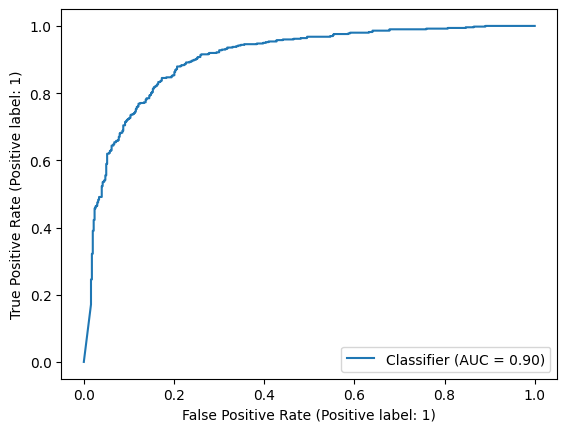

In [121]:
# On veut utiliser une la méthode from_predictions() de la classe RocCurveDisplay.
# Mettez les bons arguments dans la méthode

RocCurveDisplay.from_predictions(y_test, p_hat);

Matrice de confusion avec un seuil à 0.5:

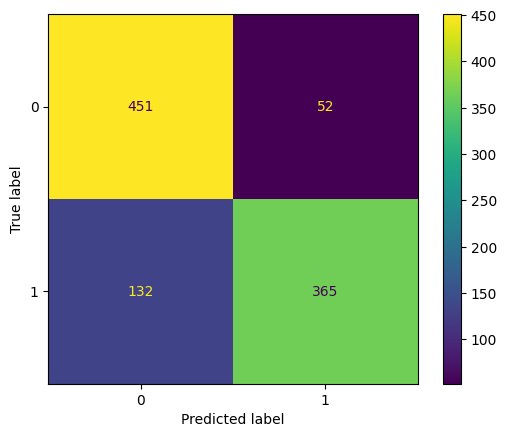

In [122]:
# On veut utiliser une la méthode from_predictions() de la classe ConfusionMatrixDisplay.

ConfusionMatrixDisplay.from_predictions(y_test, np.where(p_hat>=0.5, 1, 0));

On peut calculer la précision, le rappel ainsi que les taux des vrais positifs et faux positifs pour ce même seuil:

In [123]:
precision_score(y_test, np.where(p_hat>=0.5, 1, 0))

0.8752997601918465

In [124]:
recall_score(y_test, np.where(p_hat>=0.5, 1, 0))

0.7344064386317908

In [125]:
C = confusion_matrix(y_test, np.where(p_hat>=0.5, 1, 0))
C

array([[451,  52],
       [132, 365]], dtype=int64)

In [126]:
# Calculez le taux de vrai positif

VP = C[1, 1] # Vrai positif
FN = C[1, 0] # Faux négatif
TVP = VP / (VP + FN)  # Le taux de vrai positif est aussi le rappel
TVP

0.7344064386317908

In [127]:
# Calculez le taux de faux positif
FP = C[0, 1] # Faux positif
VN = C[0, 0] # Vrai négatif
TFP = FP / (FP + VN)
TFP

0.10337972166998012

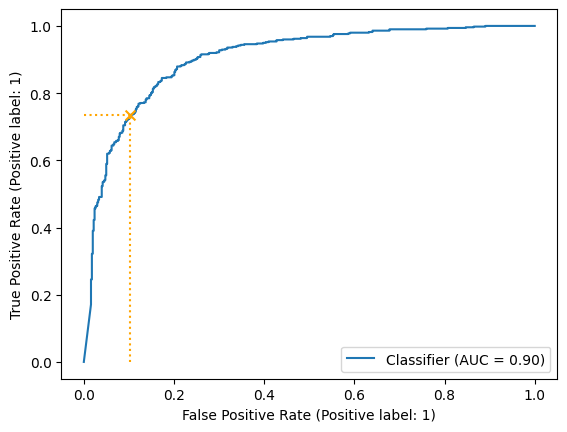

In [128]:
# On veut utiliser une la méthode from_predictions() de la classe RocCurveDisplay.
# Mettez les bons arguments dans la méthode

RocCurveDisplay.from_predictions(y_test, p_hat);
plt.gca().scatter([TFP], [TVP], color="orange", zorder=10, marker="x", s=50)
plt.gca().vlines(TFP, 0., ymax=TVP, ls=":", color="orange");
plt.gca().hlines(TVP, 0., xmax=TFP, ls=":", color="orange");

### On introduit TF-IDF !

Au lieu d'utiliser un simple compteur de mots, nous utilisons une variante un peu plus avancée. TF-IDF veut dire term frequency, inverse document frequency. Il combine deux vues:

- il va "pénaliser" des termes qui apparaissent très régulièrement et qui pourrait donc avoir un faible pouvoir prédictif. C'est le inverse document frequecy. Inversement, il "favorise" les termes peu fréquemment utilisés dans l'ensemble des documents.
- il va pénaliser les termes très utilisés au sein d'une même revue. Cela permet d'identifier des mots-vides que l'on n'aurait pas traité jusqu'à maintenant.

In [ ]:
# Entrainer et Transformer les données d'entrainement avec TfidfTransformer().

tfidf = TfidfTransformer()
x_train = tfidf.fit_transform(x_train)

In [132]:
# Entraîner un MultinomialNB(class_prior=np.array([0.5, 0.5]), fit_prior=False) sur notre set d'entrainement.

clf = MultinomialNB(class_prior=np.array([0.5, 0.5]), fit_prior=False)
clf.fit(x_train, y_train);

In [133]:
# Transformer les données d'entrainement avec TfidfTransformer().

x_test = tfidf.transform(x_test)

In [134]:
# On regarde les prédictions de notre modèle sur notre set de test.
# On utilise pour ça la méthode predict_proba()

p_hat = clf.predict_proba(x_test)[:,1]

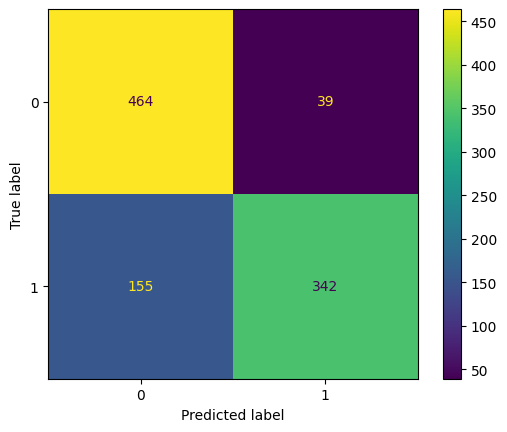

In [135]:
# On veut utiliser une la méthode from_predictions() de la classe ConfusionMatrixDisplay.

ConfusionMatrixDisplay.from_predictions(y_test, np.where(p_hat>=0.5, 1, 0));

In [136]:
precision_score(y_test, np.where(p_hat>=0.5, 1, 0))

0.8976377952755905

In [137]:
recall_score(y_test, np.where(p_hat>=0.5, 1, 0))

0.6881287726358148

In [138]:
C = confusion_matrix(y_test, np.where(p_hat>=0.5, 1, 0))
C

array([[464,  39],
       [155, 342]], dtype=int64)

In [139]:
# Calculez le taux de vrai positif
VP = C[1, 1] # Vrai positif
FN = C[1, 0] # Faux négatif
TVP = VP / (VP + FN)  # Le taux de vrai positif est aussi le rappel
TVP

0.6881287726358148

In [140]:
# Calculez le taux de fuax positif
FP = C[0, 1] # Faux positif
VN = C[0, 0] # Vrai négatif
TFP = FP / (FP + VN)
TFP

0.0775347912524851

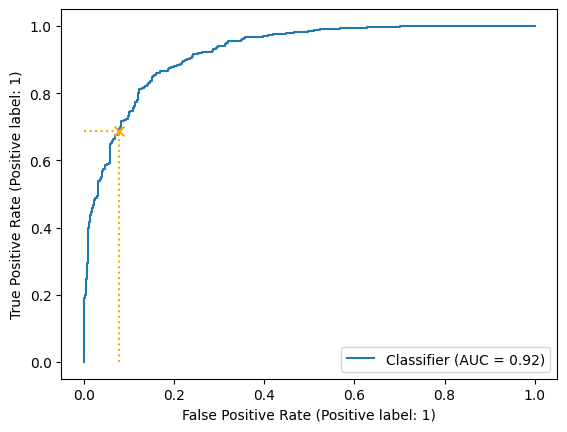

In [141]:
# On veut utiliser une la méthode from_predictions() de la classe RocCurveDisplay.
# Mettez les bons arguments dans la méthode

RocCurveDisplay.from_predictions(y_test, p_hat);
plt.gca().scatter([TFP], [TVP], color="orange", zorder=10, marker="x", s=50)
plt.gca().vlines(TFP, 0., ymax=TVP, ls=":", color="orange");
plt.gca().hlines(TVP, 0., xmax=TFP, ls=":", color="orange");

### Analyse du modèle

Quelques astuces pour identifier les n-grammes les plus significatifs sur la prise de décision de l'algorithme:

In [142]:
# Utiliser l'attribut feature_count_[c] pour compter le nombre de fois où chaque n-gramme est associé à la classe c

negative_array = clf.feature_count_[0]
positive_array = clf.feature_count_[1]

In [143]:
ratio_pos_neg = positive_array / (negative_array + 1)

In [144]:
ratio_pos_neg.max()

3.4426539096657636

In [145]:
# Ne gardons que les features dont le ratio pos_neg est supérieur à 2.0

features[ratio_pos_neg >= 2.0]

array(['amazing', 'best movie', 'brilliant', 'excellent', 'fantastic',
       'favorite', 'fulci', 'great', 'highly recommend', 'love',
       'love movie', 'powerful', 'superb', 'today', 'wonderful'],
      dtype=object)

In [146]:
ratio_neg_pos = negative_array / (positive_array + 1)

In [147]:
ratio_neg_pos.max()

7.651513623741545

In [148]:
# Ne gardons que les features dont le ratio neg_pos est supérieur à 2.0

features[ratio_neg_pos >= 2.0]

array(["'s bad", 'annoy', 'avoid', 'awful', 'bad', 'bad acting',
       'bad film', 'bad movie', 'badly', 'bore', 'boring', 'cheap',
       'crap', 'crappy', 'dull', 'fail', 'garbage', 'horrible', 'lame',
       'laughable', 'minute', 'money', 'movie bad', "n't even",
       "n't waste", 'not even', 'not funny', 'nothing', 'painful',
       'pathetic', 'pointless', 'poor', 'poorly', 'predictable',
       'really bad', 'ridiculous', 'script', 'see bad', 'stupid', 'suck',
       'suppose', 'terrible', 'time money', 'van', 'waste', 'waste time',
       'zombie'], dtype=object)

Avec un petit word cloud:

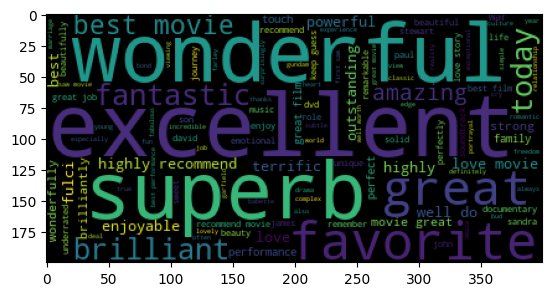

In [149]:
wrd = wordcloud.WordCloud().generate_from_frequencies({f: r for f, r in zip(features, ratio_pos_neg)})
plt.imshow(wrd);

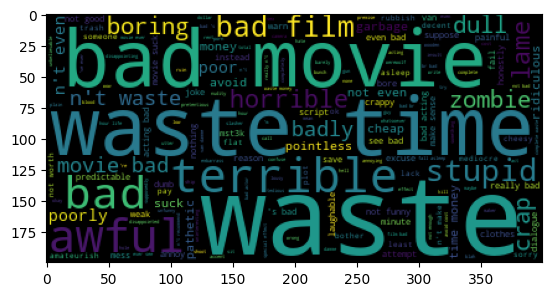

In [152]:
wrd = wordcloud.WordCloud().generate_from_frequencies({f: r for f, r in zip(features, ratio_neg_pos)})
plt.imshow(wrd);

### Tests manuels !

In [153]:
# Créer votre review et tester votre modèle dessus

def calculer_probabilite(review):
    # On tokenize
    x_test = tfidf.transform(cnt.transform([review]))
    # On calcule les probabilités
    return clf.predict_proba(x_test)[:,1]

my_review = "You should go to the closest theater, right now ! I highly recommend this movie."

calculer_probabilite(my_review)

array([0.7368249])